1. Generate data and save it

In [4]:
import numpy as np
import scipy.linalg
import os
import warnings
warnings.filterwarnings('ignore')

# All generation functions remain unchanged, but each function needs to return a type ID
# When generating each type, assign a fixed type ID to each sample
# Type ID mapping is as follows (consistent with type_to_m in the second block of code):
# 0: type1_stable, 1: type1_unstable, 2: type1_oscillatory
# 3: type2_stable, 4: type2_unstable, 5: type2_oscillatory
# 6: type3_stable, 7: type3_unstable, 8: type3_oscillatory
# 9: type4_stable, 10: type4_unstable, 11: type4_oscillatory
# 12: type5_fully_stable, 13: type5_fully_unstable, 14: type5_mixed

def generate_4d_brunovsky_type1_samples(category, num_samples, type_id):
    """Generate 4D Brunovsky-type system samples - Type [4]: fully controllable canonical form"""
    inputs, outputs, type_ids = [], [], []
    n = 4
    m = 1
    max_attempts = num_samples * 50
    attempts = 0
    
    while len(inputs) < num_samples and attempts < max_attempts:
        attempts += 1
        
        if category == "type1_stable":
            a0, a1, a2, a3 = np.random.uniform(0.1, 3, 4)
            if not (a3 > 0 and a2*a3 > a1 and a1*a2*a3 > a0*a3**2 + a1**2):
                continue
        elif category == "type1_unstable":
            a0, a1, a2, a3 = np.random.uniform(-2, 2, 4)
            A = np.array([[0, 1, 0, 0],
                         [0, 0, 1, 0],
                         [0, 0, 0, 1],
                         [-a0, -a1, -a2, -a3]])
            eig_vals = np.linalg.eig(A)[0]
            if np.max(eig_vals.real) <= 0.1:
                continue
        elif category == "type1_oscillatory":
            a0, a1, a2, a3 = np.random.uniform(-2, 2, 4)
            A = np.array([[0, 1, 0, 0],
                         [0, 0, 1, 0],
                         [0, 0, 0, 1],
                         [-a0, -a1, -a2, -a3]])
            eig_vals = np.linalg.eig(A)[0]
            if not np.any(np.abs(eig_vals.imag) > 0.1):
                continue
        
        A = np.array([[0, 1, 0, 0],
                     [0, 0, 1, 0],
                     [0, 0, 0, 1],
                     [-a0, -a1, -a2, -a3]])
        B = np.array([[0],
                     [0],
                     [0],
                     [1]])
        
        Q = np.diag(np.random.rand(n) + 0.1)
        R = np.diag(np.random.rand(m) + 0.1)
        
        try:
            P = scipy.linalg.solve_continuous_are(A, B, Q, R)
        except:
            continue
        
        B_padded = np.zeros((n, n))
        B_padded[:, :B.shape[1]] = B
        
        R_padded = np.zeros((n, n))
        R_padded[:R.shape[0], :R.shape[1]] = R
        
        input_vector = np.concatenate([
            A.flatten(),
            B_padded.flatten(),
            Q.flatten(),
            R_padded.flatten()
        ])
        
        inputs.append(input_vector)
        outputs.append(P.flatten())
        type_ids.append(type_id)   # MODIFIED: record type ID
        
        if len(inputs) % 500 == 0:
            print(f"Generated 4D Type [4] {category} samples: {len(inputs)}/{num_samples}")
    
    if len(inputs) < num_samples:
        print(f"Warning: Type [4] {category} only generated {len(inputs)}/{num_samples} samples")
    
    return np.array(inputs), np.array(outputs), np.array(type_ids)

def generate_4d_brunovsky_type2_samples(category, num_samples, type_id):
    """Generate 4D Brunovsky-type system samples - Type [3,1]"""
    inputs, outputs, type_ids = [], [], []
    n = 4
    m = 2
    max_attempts = num_samples * 100
    attempts = 0
    
    while len(inputs) < num_samples and attempts < max_attempts:
        attempts += 1
        
        if category == "type2_stable":
            a0, a1, a2 = np.random.uniform(0.1, 2, 3)
            if not (a2 > 0 and a1 > 0 and a0 > 0 and a2*a1 > a0):
                continue
            a3 = np.random.uniform(0.1, 2)
        elif category == "type2_unstable":
            if np.random.rand() > 0.5:
                a0, a1, a2 = np.random.uniform(0.1, 2, 3)
                if not (a2 > 0 and a1 > 0 and a0 > 0 and a2*a1 > a0):
                    continue
                a3 = np.random.uniform(-2, -0.1)
            else:
                a0, a1, a2 = np.random.uniform(-2, 2, 3)
                A_3d = np.array([[0, 1, 0],
                                [0, 0, 1],
                                [-a0, -a1, -a2]])
                eig_3d = np.linalg.eig(A_3d)[0]
                if np.all(eig_3d.real < 0):
                    continue
                a3 = np.random.uniform(0.1, 2)
        elif category == "type2_oscillatory":
            a0 = np.random.uniform(1, 3)
            a1 = np.random.uniform(0.5, 2)
            a2 = np.random.uniform(0.5, 2)
            a3 = np.random.uniform(0.1, 2)
        
        A = np.array([[0, 1, 0, 0],
                     [0, 0, 1, 0],
                     [-a0, -a1, -a2, 0],
                     [0, 0, 0, -a3]])
        B = np.array([[0, 0],
                     [0, 0],
                     [1, 0],
                     [0, 1]])
        
        eig_vals = np.linalg.eig(A)[0]
        valid = False
        if category == "type2_stable" and np.all(eig_vals.real < 0):
            valid = True
        elif category == "type2_unstable" and np.any(eig_vals.real > 0):
            valid = True
        elif category == "type2_oscillatory" and np.any(np.abs(eig_vals.imag) > 0.1):
            valid = True
        if not valid:
            continue
        
        Q = np.diag(np.random.rand(n) + 0.1)
        R = np.diag(np.random.rand(m) + 0.1)
        
        try:
            P = scipy.linalg.solve_continuous_are(A, B, Q, R)
        except:
            continue
        
        B_padded = np.zeros((n, n))
        B_padded[:, :B.shape[1]] = B
        R_padded = np.zeros((n, n))
        R_padded[:R.shape[0], :R.shape[1]] = R
        
        input_vector = np.concatenate([A.flatten(), B_padded.flatten(), Q.flatten(), R_padded.flatten()])
        inputs.append(input_vector)
        outputs.append(P.flatten())
        type_ids.append(type_id)   # MODIFIED
        
        if len(inputs) % 500 == 0:
            print(f"Generated 4D Type [3,1] {category} samples: {len(inputs)}/{num_samples}")
    
    if len(inputs) < num_samples:
        print(f"Warning: Type [3,1] {category} only generated {len(inputs)}/{num_samples} samples")
    
    return np.array(inputs), np.array(outputs), np.array(type_ids)

def generate_4d_brunovsky_type3_samples(category, num_samples, type_id):
    """Generate 4D Brunovsky-type system samples - Type [2,2]"""
    inputs, outputs, type_ids = [], [], []
    n = 4
    m = 2
    max_attempts = num_samples * 50
    attempts = 0
    
    while len(inputs) < num_samples and attempts < max_attempts:
        attempts += 1
        
        if category == "type3_stable":
            a0, a1 = np.random.uniform(0.1, 2, 2)
            b0, b1 = np.random.uniform(0.1, 2, 2)
        elif category == "type3_unstable":
            if np.random.rand() > 0.5:
                a0, a1 = np.random.uniform(0.1, 2, 2)
                b0, b1 = np.random.uniform(-2, -0.1, 2)
            else:
                a0, a1 = np.random.uniform(-2, -0.1, 2)
                b0, b1 = np.random.uniform(0.1, 2, 2)
        elif category == "type3_oscillatory":
            if np.random.rand() > 0.5:
                a0 = np.random.uniform(1, 2)
                a1 = np.random.uniform(0.5, 1.5)
                b0, b1 = np.random.uniform(0.1, 2, 2)
            else:
                a0, a1 = np.random.uniform(0.1, 2, 2)
                b0 = np.random.uniform(1, 2)
                b1 = np.random.uniform(0.5, 1.5)
        
        A = np.array([[0, 1, 0, 0],
                     [-a0, -a1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, -b0, -b1]])
        B = np.array([[0, 0],
                     [1, 0],
                     [0, 0],
                     [0, 1]])
        
        eig_vals = np.linalg.eig(A)[0]
        valid = False
        if category == "type3_stable" and np.all(eig_vals.real < 0):
            valid = True
        elif category == "type3_unstable" and np.any(eig_vals.real > 0):
            valid = True
        elif category == "type3_oscillatory" and np.any(np.abs(eig_vals.imag) > 0.1):
            valid = True
        if not valid:
            continue
        
        Q = np.diag(np.random.rand(n) + 0.1)
        R = np.diag(np.random.rand(m) + 0.1)
        
        try:
            P = scipy.linalg.solve_continuous_are(A, B, Q, R)
        except:
            continue
        
        B_padded = np.zeros((n, n))
        B_padded[:, :B.shape[1]] = B
        R_padded = np.zeros((n, n))
        R_padded[:R.shape[0], :R.shape[1]] = R
        
        input_vector = np.concatenate([A.flatten(), B_padded.flatten(), Q.flatten(), R_padded.flatten()])
        inputs.append(input_vector)
        outputs.append(P.flatten())
        type_ids.append(type_id)   # MODIFIED
        
        if len(inputs) % 500 == 0:
            print(f"Generated 4D Type [2,2] {category} samples: {len(inputs)}/{num_samples}")
    
    if len(inputs) < num_samples:
        print(f"Warning: Type [2,2] {category} only generated {len(inputs)}/{num_samples} samples")
    
    return np.array(inputs), np.array(outputs), np.array(type_ids)

def generate_4d_brunovsky_type4_samples(category, num_samples, type_id):
    """Generate 4D Brunovsky-type system samples - Type [2,1,1]"""
    inputs, outputs, type_ids = [], [], []
    n = 4
    m = 3
    max_attempts = num_samples * 80
    attempts = 0
    
    while len(inputs) < num_samples and attempts < max_attempts:
        attempts += 1
        
        if category == "type4_stable":
            a0, a1 = np.random.uniform(0.1, 2, 2)
            b0, c0 = np.random.uniform(0.1, 2, 2)
        elif category == "type4_unstable":
            pattern = np.random.randint(0, 4)
            if pattern == 0:
                a0, a1 = np.random.uniform(0.1, 2, 2)
                b0, c0 = np.random.uniform(-2, -0.1, 2)
            elif pattern == 1:
                a0, a1 = np.random.uniform(-2, -0.1, 2)
                b0, c0 = np.random.uniform(0.1, 2, 2)
            elif pattern == 2:
                a0, a1 = np.random.uniform(0.1, 2, 2)
                b0 = np.random.uniform(-2, -0.1)
                c0 = np.random.uniform(0.1, 2)
            else:
                a0, a1 = np.random.uniform(0.1, 2, 2)
                b0 = np.random.uniform(0.1, 2)
                c0 = np.random.uniform(-2, -0.1)
        elif category == "type4_oscillatory":
            a0 = np.random.uniform(1, 2)
            a1 = np.random.uniform(0.5, 1.5)
            b0, c0 = np.random.uniform(0.1, 2, 2)
        
        A = np.array([[0, 1, 0, 0],
                     [-a0, -a1, 0, 0],
                     [0, 0, -b0, 0],
                     [0, 0, 0, -c0]])
        B = np.array([[0, 0, 0],
                     [1, 0, 0],
                     [0, 1, 0],
                     [0, 0, 1]])
        
        eig_vals = np.linalg.eig(A)[0]
        valid = False
        if category == "type4_stable" and np.all(eig_vals.real < 0):
            valid = True
        elif category == "type4_unstable" and np.any(eig_vals.real > 0):
            valid = True
        elif category == "type4_oscillatory" and np.any(np.abs(eig_vals.imag) > 0.1):
            valid = True
        if not valid:
            continue
        
        Q = np.diag(np.random.rand(n) + 0.1)
        R = np.diag(np.random.rand(m) + 0.1)
        
        try:
            P = scipy.linalg.solve_continuous_are(A, B, Q, R)
        except:
            continue
        
        B_padded = np.zeros((n, n))
        B_padded[:, :B.shape[1]] = B
        R_padded = np.zeros((n, n))
        R_padded[:R.shape[0], :R.shape[1]] = R
        
        input_vector = np.concatenate([A.flatten(), B_padded.flatten(), Q.flatten(), R_padded.flatten()])
        inputs.append(input_vector)
        outputs.append(P.flatten())
        type_ids.append(type_id)   # MODIFIED
        
        if len(inputs) % 500 == 0:
            print(f"Generated 4D Type [2,1,1] {category} samples: {len(inputs)}/{num_samples}")
    
    if len(inputs) < num_samples:
        print(f"Warning: Type [2,1,1] {category} only generated {len(inputs)}/{num_samples} samples")
    
    return np.array(inputs), np.array(outputs), np.array(type_ids)

def generate_4d_brunovsky_type5_samples(category, num_samples, type_id):
    """Generate 4D Brunovsky-type system samples - Type [1,1,1,1]"""
    inputs, outputs, type_ids = [], [], []
    n = 4
    m = 4
    
    while len(inputs) < num_samples:
        if category == "type5_fully_stable":
            a0, a1, a2, a3 = np.random.uniform(-2, -0.1, 4)
        elif category == "type5_fully_unstable":
            a0, a1, a2, a3 = np.random.uniform(0.1, 2, 4)
        elif category == "type5_mixed":
            stable_count = np.random.randint(1, 4)
            unstable_count = 4 - stable_count
            stable_vals = np.random.uniform(-2, -0.1, stable_count)
            unstable_vals = np.random.uniform(0.1, 2, unstable_count)
            all_vals = np.concatenate([stable_vals, unstable_vals])
            np.random.shuffle(all_vals)
            a0, a1, a2, a3 = all_vals
        
        A = np.array([[a0, 0, 0, 0],
                     [0, a1, 0, 0],
                     [0, 0, a2, 0],
                     [0, 0, 0, a3]])
        B = np.eye(4)
        
        eig_vals = np.linalg.eig(A)[0]
        valid = False
        if category == "type5_fully_stable" and np.all(eig_vals.real < 0):
            valid = True
        elif category == "type5_fully_unstable" and np.all(eig_vals.real > 0):
            valid = True
        elif category == "type5_mixed" and np.any(eig_vals.real > 0) and np.any(eig_vals.real < 0):
            valid = True
        if not valid:
            continue
        
        Q = np.diag(np.random.rand(n) + 0.1)
        R = np.diag(np.random.rand(m) + 0.1)
        
        try:
            P = scipy.linalg.solve_continuous_are(A, B, Q, R)
        except:
            continue
        
        input_vector = np.concatenate([A.flatten(), B.flatten(), Q.flatten(), R.flatten()])
        inputs.append(input_vector)
        outputs.append(P.flatten())
        type_ids.append(type_id)   # MODIFIED
        
        if len(inputs) % 500 == 0:
            print(f"Generated 4D Type [1,1,1,1] {category} samples: {len(inputs)}/{num_samples}")
    
    return np.array(inputs), np.array(outputs), np.array(type_ids)

def split_data_by_type(inputs_list, outputs_list, type_ids_list, train_ratio=0.95):
    """Split training and test sets by type, also splitting type labels"""
    train_inputs, train_outputs, train_type_ids = [], [], []
    test_inputs, test_outputs, test_type_ids = [], [], []
    
    for inputs, outputs, type_ids in zip(inputs_list, outputs_list, type_ids_list):
        split_idx = int(len(inputs) * train_ratio)
        train_inputs.append(inputs[:split_idx])
        train_outputs.append(outputs[:split_idx])
        train_type_ids.append(type_ids[:split_idx])
        
        test_inputs.append(inputs[split_idx:])
        test_outputs.append(outputs[split_idx:])
        test_type_ids.append(type_ids[split_idx:])
    
    # Vertically stack all training/test data
    train_inputs = np.vstack(train_inputs)
    train_outputs = np.vstack(train_outputs)
    train_type_ids = np.concatenate(train_type_ids)
    
    test_inputs = np.vstack(test_inputs)
    test_outputs = np.vstack(test_outputs)
    test_type_ids = np.concatenate(test_type_ids)
    
    return (train_inputs, train_outputs, train_type_ids,
            test_inputs, test_outputs, test_type_ids)

if __name__ == "__main__":
    print("Generating 4D Brunovsky-type system samples...")

    # Define type IDs
    type_id_counter = 0

    # Type [4]
    print("\nGenerating Type [4] samples...")
    t1s_in, t1s_out, t1s_id = generate_4d_brunovsky_type1_samples('type1_stable', 3500, type_id_counter); type_id_counter += 1
    t1u_in, t1u_out, t1u_id = generate_4d_brunovsky_type1_samples('type1_unstable', 1000, type_id_counter); type_id_counter += 1
    t1o_in, t1o_out, t1o_id = generate_4d_brunovsky_type1_samples('type1_oscillatory', 1000, type_id_counter); type_id_counter += 1

    # Type [3,1]
    print("\nGenerating Type [3,1] samples...")
    t2s_in, t2s_out, t2s_id = generate_4d_brunovsky_type2_samples('type2_stable', 3500, type_id_counter); type_id_counter += 1
    t2u_in, t2u_out, t2u_id = generate_4d_brunovsky_type2_samples('type2_unstable', 1000, type_id_counter); type_id_counter += 1
    t2o_in, t2o_out, t2o_id = generate_4d_brunovsky_type2_samples('type2_oscillatory', 1000, type_id_counter); type_id_counter += 1

    # Type [2,2]
    print("\nGenerating Type [2,2] samples...")
    t3s_in, t3s_out, t3s_id = generate_4d_brunovsky_type3_samples('type3_stable', 1000, type_id_counter); type_id_counter += 1
    t3u_in, t3u_out, t3u_id = generate_4d_brunovsky_type3_samples('type3_unstable', 1000, type_id_counter); type_id_counter += 1
    t3o_in, t3o_out, t3o_id = generate_4d_brunovsky_type3_samples('type3_oscillatory', 1000, type_id_counter); type_id_counter += 1

    # Type [2,1,1]
    print("\nGenerating Type [2,1,1] samples...")
    t4s_in, t4s_out, t4s_id = generate_4d_brunovsky_type4_samples('type4_stable', 1000, type_id_counter); type_id_counter += 1
    t4u_in, t4u_out, t4u_id = generate_4d_brunovsky_type4_samples('type4_unstable', 1000, type_id_counter); type_id_counter += 1
    t4o_in, t4o_out, t4o_id = generate_4d_brunovsky_type4_samples('type4_oscillatory', 1000, type_id_counter); type_id_counter += 1

    # Type [1,1,1,1]
    print("\nGenerating Type [1,1,1,1] samples...")
    t5s_in, t5s_out, t5s_id = generate_4d_brunovsky_type5_samples('type5_fully_stable', 1000, type_id_counter); type_id_counter += 1
    t5u_in, t5u_out, t5u_id = generate_4d_brunovsky_type5_samples('type5_fully_unstable', 1000, type_id_counter); type_id_counter += 1
    t5m_in, t5m_out, t5m_id = generate_4d_brunovsky_type5_samples('type5_mixed', 1000, type_id_counter); type_id_counter += 1

    print("\nData generation completed:")
    print(f"Type [4] - Stable: {len(t1s_in)}, Unstable: {len(t1u_in)}, Oscillatory: {len(t1o_in)}")
    print(f"Type [3,1] - Stable: {len(t2s_in)}, Unstable: {len(t2u_in)}, Oscillatory: {len(t2o_in)}")
    print(f"Type [2,2] - Stable: {len(t3s_in)}, Unstable: {len(t3u_in)}, Oscillatory: {len(t3o_in)}")
    print(f"Type [2,1,1] - Stable: {len(t4s_in)}, Unstable: {len(t4u_in)}, Oscillatory: {len(t4o_in)}")
    print(f"Type [1,1,1,1] - Fully stable: {len(t5s_in)}, Fully unstable: {len(t5u_in)}, Mixed: {len(t5m_in)}")

    # Combine all data lists (order must be consistent with type IDs)
    all_inputs_list = [
        t1s_in, t1u_in, t1o_in,
        t2s_in, t2u_in, t2o_in,
        t3s_in, t3u_in, t3o_in,
        t4s_in, t4u_in, t4o_in,
        t5s_in, t5u_in, t5m_in
    ]
    all_outputs_list = [
        t1s_out, t1u_out, t1o_out,
        t2s_out, t2u_out, t2o_out,
        t3s_out, t3u_out, t3o_out,
        t4s_out, t4u_out, t4o_out,
        t5s_out, t5u_out, t5m_out
    ]
    all_type_ids_list = [
        t1s_id, t1u_id, t1o_id,
        t2s_id, t2u_id, t2o_id,
        t3s_id, t3u_id, t3o_id,
        t4s_id, t4u_id, t4o_id,
        t5s_id, t5u_id, t5m_id
    ]

    # Split training/test sets
    (train_inputs, train_outputs, train_type_ids,
     test_inputs, test_outputs, test_type_ids) = split_data_by_type(
        all_inputs_list, all_outputs_list, all_type_ids_list, train_ratio=0.95
    )

    print(f"\nTotal training set: {len(train_inputs)}, Total test set: {len(test_inputs)}")

    # Create data folder and save
    data_dir = "./4D"
    os.makedirs(data_dir, exist_ok=True)
    save_path = os.path.join(data_dir, "brunovsky_data.npz")
    np.savez(save_path,
             train_inputs=train_inputs,
             train_outputs=train_outputs,
             test_inputs=test_inputs,
             test_outputs=test_outputs,
             train_type_ids=train_type_ids,
             test_type_ids=test_type_ids)
    print(f"Data saved to {save_path}")

Generating 4D Brunovsky-type system samples...

Generating Type [4] samples...
Generated 4D Type [4] type1_stable samples: 500/3500
Generated 4D Type [4] type1_stable samples: 1000/3500
Generated 4D Type [4] type1_stable samples: 1500/3500
Generated 4D Type [4] type1_stable samples: 2000/3500
Generated 4D Type [4] type1_stable samples: 2500/3500
Generated 4D Type [4] type1_stable samples: 3000/3500
Generated 4D Type [4] type1_stable samples: 3500/3500
Generated 4D Type [4] type1_unstable samples: 500/1000
Generated 4D Type [4] type1_unstable samples: 1000/1000
Generated 4D Type [4] type1_oscillatory samples: 500/1000
Generated 4D Type [4] type1_oscillatory samples: 1000/1000

Generating Type [3,1] samples...
Generated 4D Type [3,1] type2_stable samples: 500/3500
Generated 4D Type [3,1] type2_stable samples: 1000/3500
Generated 4D Type [3,1] type2_stable samples: 1500/3500
Generated 4D Type [3,1] type2_stable samples: 2000/3500
Generated 4D Type [3,1] type2_stable samples: 2500/3500
Gen

2. Train the model and save it 

Using device: cuda
Training set: (19000, 64), Test set: (1000, 64)
Type labels loaded, training set type distribution: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), array([3325,  950,  950, 3325,  950,  950,  950,  950,  950,  950,  950,
        950,  950,  950,  950]))
Position grid shape: (16, 2)
Number of model parameters: 494,849
Starting training...
Epoch [100/3000], Train Loss: 2.571149, Test Loss: 2.485006, LR: 0.000100
Epoch [200/3000], Train Loss: 0.675797, Test Loss: 0.606177, LR: 0.000100
Epoch [300/3000], Train Loss: 0.424496, Test Loss: 0.406265, LR: 0.000100
Epoch [400/3000], Train Loss: 0.323923, Test Loss: 0.310404, LR: 0.000100
Epoch [500/3000], Train Loss: 0.255294, Test Loss: 0.245078, LR: 0.000100
Epoch [600/3000], Train Loss: 0.208154, Test Loss: 0.201343, LR: 0.000100
Epoch [700/3000], Train Loss: 0.169900, Test Loss: 0.164445, LR: 0.000100
Epoch [800/3000], Train Loss: 0.145146, Test Loss: 0.139515, LR: 0.000100
Epoch [900/3000], Train Los

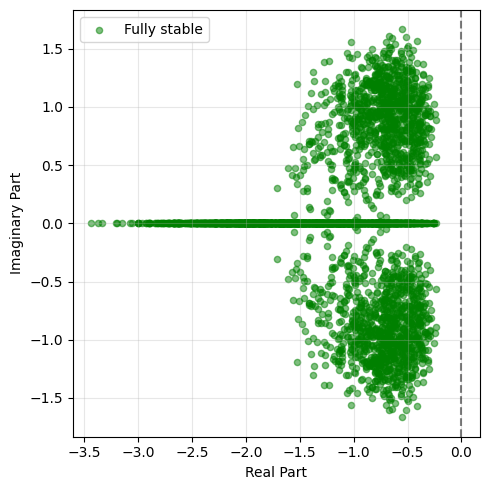

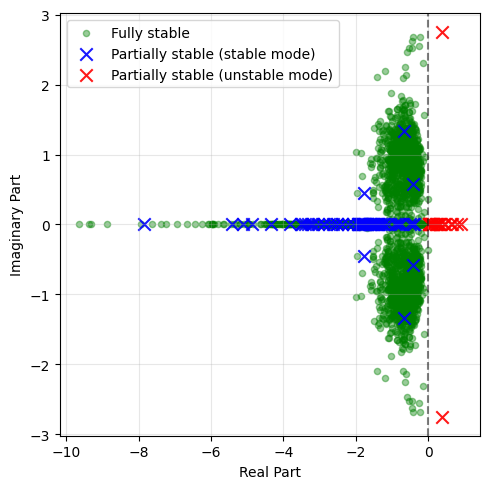

In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time

# -------------------- Device setup --------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# -------------------- Load data --------------------
data_path = os.path.join("./4D", "brunovsky_data.npz")
data = np.load(data_path)

train_inputs = data['train_inputs']
train_outputs = data['train_outputs']
test_inputs = data['test_inputs']
test_outputs = data['test_outputs']
train_type_ids = data['train_type_ids']   # training set type labels
test_type_ids = data['test_type_ids']     # test set type labels

print(f"Training set: {train_inputs.shape}, Test set: {test_inputs.shape}")
print(f"Type labels loaded, training set type distribution: {np.unique(train_type_ids, return_counts=True)}")

# -------------------- Generate position grid --------------------
def generate_position_grid(rows=4, cols=4):
    grid = []
    for i in range(rows):
        for j in range(cols):
            x_norm = i / (rows - 1) if rows > 1 else 0.5
            y_norm = j / (cols - 1) if cols > 1 else 0.5
            grid.append([x_norm, y_norm])
    return np.array(grid)

position_grid = generate_position_grid(4, 4)
print(f"Position grid shape: {position_grid.shape}")

# -------------------- Convert to tensors --------------------
train_branch = torch.FloatTensor(train_inputs).to(device)
train_output = torch.FloatTensor(train_outputs).to(device)
train_grid = torch.FloatTensor(np.tile(position_grid, (len(train_inputs), 1, 1))).to(device)

test_branch = torch.FloatTensor(test_inputs).to(device)
test_output = torch.FloatTensor(test_outputs).to(device)
test_grid = torch.FloatTensor(np.tile(position_grid, (len(test_inputs), 1, 1))).to(device)

# -------------------- Define DeepONet model --------------------
class DeepONet(nn.Module):
    def __init__(self, branch_input_dim=64, trunk_input_dim=2, hidden_dim=512):
        super().__init__()
        self.branch_net = nn.Sequential(
            nn.Linear(branch_input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, hidden_dim)
        )
        self.trunk_net = nn.Sequential(
            nn.Linear(trunk_input_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, hidden_dim)
        )
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, branch_input, trunk_input):
        branch_out = self.branch_net(branch_input)                     # (batch, hidden)
        batch_size, num_points, coord_dim = trunk_input.shape
        trunk_flat = trunk_input.view(-1, coord_dim)                   # (batch*num, 2)
        trunk_out = self.trunk_net(trunk_flat)                         # (batch*num, hidden)
        trunk_out = trunk_out.view(batch_size, num_points, -1)         # (batch, num, hidden)
        branch_out = branch_out.unsqueeze(1)                           # (batch, 1, hidden)
        combined = branch_out * trunk_out                              # (batch, num, hidden)
        output = self.output_layer(combined).squeeze(-1)               # (batch, num)
        return output

# Create model
model = DeepONet(hidden_dim=512).to(device)
print(f"Number of model parameters: {sum(p.numel() for p in model.parameters()):,}")

# -------------------- Training parameters --------------------
num_epochs = 3000
learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50)

train_losses = []
test_losses = []

print("Starting training...")
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    train_pred = model(train_branch, train_grid)
    train_loss = criterion(train_pred, train_output)
    train_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = model(test_branch, test_grid)
        test_loss = criterion(test_pred, test_output)

    scheduler.step(test_loss)

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

    if (epoch + 1) % 100 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss.item():.6f}, '
              f'Test Loss: {test_loss.item():.6f}, '
              f'LR: {current_lr:.6f}')

end_time = time.time()
total_time = end_time - start_time
hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = total_time % 60
print(f"\nTraining completed! Total time: {hours}h {minutes}m {seconds:.2f}s")

# -------------------- Save model to data folder --------------------
model_save_path = os.path.join("./4D", "deeponet_standard_model.pth")
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# -------------------- Closed-loop stability evaluation --------------------
print("\nStarting closed-loop stability evaluation...")
model.eval()
with torch.no_grad():
    test_pred = model(test_branch, test_grid).cpu().numpy()  # predicted P matrices (flattened)

# True P matrices (from test labels)
true_P = test_outputs  # shape: (N, 16)

# Define type mapping to determine m for each sample
# Type indices consistent with generation order
type_to_m = {
    0: 1,   # type1_stable
    1: 1,   # type1_unstable
    2: 1,   # type1_oscillatory
    3: 2,   # type2_stable
    4: 2,   # type2_unstable
    5: 2,   # type2_oscillatory
    6: 2,   # type3_stable
    7: 2,   # type3_unstable
    8: 2,   # type3_oscillatory
    9: 3,   # type4_stable
    10: 3,  # type4_unstable
    11: 3,  # type4_oscillatory
    12: 4,  # type5_fully_stable
    13: 4,  # type5_fully_unstable
    14: 4,  # type5_mixed
}

# Collect eigenvalues
true_eigs_list = []
pred_eigs_list = []

# Count stable samples
stable_sample_count = 0
total_samples = len(test_inputs)

# Count stable eigenvalues
stable_eig_count = 0
total_eig_count = total_samples * 4  # 4 eigenvalues per sample

for i in range(total_samples):
    # Get type and m
    type_id = test_type_ids[i]
    m = type_to_m[type_id]

    # Reconstruct A, B, R from input vector
    input_vec = test_inputs[i]
    # A: 16 elements, reshape to 4x4
    A = input_vec[:16].reshape(4, 4)
    # B_padded: next 16 elements
    B_padded = input_vec[16:32].reshape(4, 4)
    # Extract actual B (4 x m)
    B = B_padded[:, :m]
    # R_padded: last 16 elements (Q is skipped, but actual order is Q then R_padded, need to confirm)
    R_padded = input_vec[48:64].reshape(4, 4)
    # Extract actual R (m x m)
    R = R_padded[:m, :m]

    # Ensure R is diagonal positive definite (guaranteed by generation)
    R_inv = np.linalg.inv(R)

    # True P
    P_true = true_P[i].reshape(4, 4)
    # Predicted P
    P_pred = test_pred[i].reshape(4, 4)

    # Compute gain matrix K (m x 4)
    K_true = R_inv @ B.T @ P_true
    K_pred = R_inv @ B.T @ P_pred

    # Compute closed-loop system matrices
    A_cl_true = A - B @ K_true
    A_cl_pred = A - B @ K_pred

    # Compute eigenvalues
    eig_true = np.linalg.eigvals(A_cl_true)
    eig_pred = np.linalg.eigvals(A_cl_pred)

    # Collect
    true_eigs_list.append(eig_true)
    pred_eigs_list.append(eig_pred)

    # Determine if predicted closed-loop is stable (all real parts < 0)
    if np.all(eig_pred.real < 0):
        stable_sample_count += 1

    # Count stable eigenvalues in predictions
    stable_eig_count += np.sum(eig_pred.real < 0)

# Compute probabilities
stable_sample_prob = stable_sample_count / total_samples * 100
stable_eig_prob = stable_eig_count / total_eig_count * 100

print("\n======= Closed-loop stability evaluation results =======")
print(f"Total test samples: {total_samples}")
print(f"Number of predicted stable samples: {stable_sample_count}")
print(f"Proportion of predicted stable samples: {stable_sample_prob:.2f}%")
print(f"Total number of eigenvalues: {total_eig_count}")
print(f"Number of predicted stable eigenvalues: {stable_eig_count}")
print(f"Proportion of predicted stable eigenvalues: {stable_eig_prob:.2f}%")


# -------------------- Collect eigenvalue data with classification information --------------------
true_eigen_list = []   # store true eigenvalues with their system info
pred_eigen_list = []   # store predicted eigenvalues with their system info

for i in range(total_samples):
    # True closed-loop eigenvalues
    eig_true = true_eigs_list[i]   # note: true_eigs_list is list of eigenvalue arrays for each sample
    true_system_stable = np.all(eig_true.real < 0)   # whether true closed-loop system is stable
    for eig in eig_true:
        true_eigen_list.append({
            'type': 'True',
            'system_stable': true_system_stable,
            'real': eig.real,
            'imag': eig.imag
        })

    # Predicted closed-loop eigenvalues
    eig_pred = pred_eigs_list[i]
    pred_system_stable = np.all(eig_pred.real < 0)   # whether predicted closed-loop system is stable
    for eig in eig_pred:
        pred_eigen_list.append({
            'type': 'Pred',
            'system_stable': pred_system_stable,
            'real': eig.real,
            'imag': eig.imag
        })

# -------------------- Plot eigenvalue distribution for true closed-loop system --------------------
plt.figure(figsize=(5, 5))

# Classification: eigenvalues from stable systems
stable_true = [e for e in true_eigen_list if e['system_stable']]
# Eigenvalues from unstable systems, further divided by sign of real part
unstable_left_true = [e for e in true_eigen_list if not e['system_stable'] and e['real'] < 0]
unstable_right_true = [e for e in true_eigen_list if not e['system_stable'] and e['real'] >= 0]

if stable_true:
    plt.scatter([e['real'] for e in stable_true], [e['imag'] for e in stable_true],
                c='green', marker='o', label='Fully stable', alpha=0.5, s=20)
if unstable_left_true:
    plt.scatter([e['real'] for e in unstable_left_true], [e['imag'] for e in unstable_left_true],
                c='blue', marker='x', label='Partially stable (stable mode)', alpha=0.9, s=60)
if unstable_right_true:
    plt.scatter([e['real'] for e in unstable_right_true], [e['imag'] for e in unstable_right_true],
                c='red', marker='x', label='Partially stable (unstable mode)', alpha=0.9, s=60)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join("./4D", "true_eigenvalues_classified.png"), dpi=300)
plt.show()

# -------------------- Plot eigenvalue distribution for predicted closed-loop system --------------------
plt.figure(figsize=(5, 5))

stable_pred = [e for e in pred_eigen_list if e['system_stable']]
unstable_left_pred = [e for e in pred_eigen_list if not e['system_stable'] and e['real'] < 0]
unstable_right_pred = [e for e in pred_eigen_list if not e['system_stable'] and e['real'] >= 0]

if stable_pred:
    plt.scatter([e['real'] for e in stable_pred], [e['imag'] for e in stable_pred],
                c='green', marker='o', label='Fully stable', alpha=0.4, s=20)
if unstable_left_pred:
    plt.scatter([e['real'] for e in unstable_left_pred], [e['imag'] for e in unstable_left_pred],
                c='blue', marker='x', label='Partially stable (stable mode)', alpha=0.9, s=80)
if unstable_right_pred:
    plt.scatter([e['real'] for e in unstable_right_pred], [e['imag'] for e in unstable_right_pred],
                c='red', marker='x', label='Partially stable (unstable mode)', alpha=0.9, s=80)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join("./4D", "pred_eigenvalues_classified.png"), dpi=300)
plt.show()